## Step 1: Load the snapshot

In [2]:
import pandas as pd

# Load your combined CSV
df = pd.read_csv(r"C:\Users\tlili\OneDrive\Bureau\Bootcamp\final\AI-powered-cryptocurrency-market-analysis-and-decision-support-system\data\raw\crypto_market_snapshot_2026-02-11.csv")

# Quick view
print(df.shape)
df.head()


(732, 10)


,timestamp,price,market_cap,volume,coin,market_cap_rank,circulating_supply,max_supply,ath,atl
0,2025-02-12 00:00:00,95739.977371,1.898789e+12,3.645458e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
1,2025-02-13 00:00:00,97836.188561,1.936842e+12,4.711562e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
2,2025-02-14 00:00:00,96561.663999,1.914315e+12,2.908437e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
3,2025-02-15 00:00:00,97488.481485,1.931657e+12,3.228991e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
4,2025-02-16 00:00:00,97569.951694,1.934308e+12,1.421531e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81


## Step 2: check the data 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           732 non-null    object 
 1   price               732 non-null    float64
 2   market_cap          732 non-null    float64
 3   volume              732 non-null    float64
 4   coin                732 non-null    object 
 5   market_cap_rank     732 non-null    int64  
 6   circulating_supply  732 non-null    float64
 7   max_supply          366 non-null    float64
 8   ath                 732 non-null    float64
 9   atl                 732 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 57.3+ KB


In [4]:
df.shape


(732, 10)

In [5]:
#check the missing values 
(df.isnull().sum())

timestamp               0
price                   0
market_cap              0
volume                  0
coin                    0
market_cap_rank         0
circulating_supply      0
max_supply            366
ath                     0
atl                     0
dtype: int64

In [6]:
df.groupby("coin")["max_supply"].agg(
    non_null_count="count",
    total_rows="size",
    unique_values="nunique",
    value="first"
)

,non_null_count,total_rows,unique_values,value
coin,,,,
bitcoin,366,366,1,21000000.0
ethereum,0,366,0,NaN


* Bitcoin has a defined max_supply = 21,000,000
Ethereum has no fixed max supply which explaines why the max_supply column is null for ETH 
This is a semantic missingness, not a data quality issue. we will address this later in the feature engineering stage by setting a binary flag (1 is max supply exists else 0)

In [7]:
#check duplicates 
(df.duplicated().sum())

np.int64(0)

In [8]:
#data type check 
(df.dtypes)

timestamp              object
price                 float64
market_cap            float64
volume                float64
coin                   object
market_cap_rank         int64
circulating_supply    float64
max_supply            float64
ath                   float64
atl                   float64
dtype: object

* the timestamp feature is in object type we will convert it to datetime in the data preprocessing stage ( that is mandatory )

In [9]:
#identify which columns are likely categorical
(df.nunique())

timestamp             367
price                 732
market_cap            732
volume                732
coin                    2
market_cap_rank         2
circulating_supply      2
max_supply              1
ath                     2
atl                     2
dtype: int64

* i noticed that the "circulating_supply" feature is not historical but rather a snapshot value taken at the time of the data extraction, in the feature engineering stage we will compute a new feature " circulation_supply_history" using the marketcap and price features which will be much better then a static snapshot value 

* ath ( all time high ) and atl ( all time low ) have a single unique value per coin captured at the time os the snapshot, they don't vary over time but we will keepthem to extract a new feature "distance from ath" and "distance from atl" in the feature engineering stage.

In [10]:
#check the abnormal values (Price, market cap, volume must be > 0)
numeric_cols = ["price", "market_cap", "volume"]

for col in numeric_cols:
    print(col, (df[col] <= 0).sum())

price 0
market_cap 0
volume 0


## Step 3: Data preprocessing 

In [11]:
# round the values 
df["price"] = df["price"].round(2)
df["market_cap"] = df["market_cap"].round(0)
df["volume"] = df["volume"].round(0)
df["circulating_supply"] = df["circulating_supply"].round(0)
df["max_supply"] = df["max_supply"].round(0)
df["ath"] = df["ath"].round(2)
df["atl"] = df["atl"].round(2)


In [12]:
#Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])


In [13]:
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,circulating_supply,max_supply,ath,atl
0,2025-02-12,95739.98,1.898789e+12,3.645458e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
1,2025-02-13,97836.19,1.936842e+12,4.711562e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
2,2025-02-14,96561.66,1.914315e+12,2.908437e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
3,2025-02-15,97488.48,1.931657e+12,3.228991e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81
4,2025-02-16,97569.95,1.934308e+12,1.421531e+10,bitcoin,1,19987365.0,21000000.0,126080.0,67.81


## Step 4: Feature engineering 

* We will create a new feature that measures change in price from one day to the next, providing insights into the coin's daily performance and volatility​​ 
- log returns= ln(Price today/Price yesterday)
- this feature will replace the price_change_24h and price_change_percentage_24h features which are snapshot values and remain constant across the historical dataset.


In [14]:
import numpy as np

df = df.sort_values(["coin", "timestamp"])

df["log_return_1d"] = (
    df.groupby("coin")["price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


* we will create a new feature to mesure the rolling risk of the coin in a given period (7 days, 14 days) 
So instead of just knowing today s return, we know how unstable or risky the coin is in the last period. 


In [15]:
df["volatility_7d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)

df["volatility_14d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)

* we will create a new feature for the RSI 14 day (relative strength index) which evaluates the overbought or oversold condition of a coin base on its recent price movements

In [16]:
window = 14

delta = df.groupby("coin")["price"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))


* we will create a new feature for the market structure ratio 

- High value → high trading activity
- Low value → illiquid or sleepy market


In [17]:
df["volume_to_marketcap"] = df["volume"] / df["market_cap"]


* we will compute a new feature "circulating_supply_history" using the marketcap and price features which will replace the circulating_supply snapshot.

In [18]:
df["circulating_supply_history"] = df["market_cap"] / df["price"]

In [19]:
df["circulating_supply_history"] = df["circulating_supply_history"].round(0)

In [20]:
df = df.drop(columns=["circulating_supply"])

* we will add 2 features ATH / ATL distance features : 
- Near ATH → bullish regime
- Near ATL → distress regime

In [21]:
df["distance_from_ath"] = (df["price"] - df["ath"]) / df["ath"]
df["distance_from_atl"] = (df["price"] - df["atl"]) / df["atl"]

* As the max supply feature has a semantic missingness ( it is null for coins that have no max supply like ETH) we will create a binary flag for the max supply feature 1 if there is max supply else 0
- this feature will replace the max supply feature 

In [22]:
#Create a binary flag for the max supply feature 1 if there is max supply else 0
df["has_max_supply"] = df["max_supply"].notna().astype(int)

In [23]:
cols_to_drop = [
    "max_supply",
]
df = df.drop(columns=cols_to_drop)


* Rolling features such as volatility and RSI require a historical window of 7–14 days. The 14 first rows per coin do not have sufficient data to compute these indicators and will contain Nan values . instead of dropping the rows we will fill them as we have a small dataset and we don't want to lose data . 

In [24]:
# FILL NaNs STRATEGY (instead of dropping rows)

# Strategy for volatility: Fill with 0 (no volatility calculated yet)
df["volatility_7d"] = df["volatility_7d"].fillna(0)
df["volatility_14d"] = df["volatility_14d"].fillna(0)

# Strategy for RSI: Fill with 50 (neutral RSI - neither overbought nor oversold)
df["rsi_14"] = df["rsi_14"].fillna(50)

# Verify no NaNs remain in these features
print("NaNs filled successfully!")
print(f"Total rows retained: {len(df)}")
print("\nNaN count per column:")
print(df[["volatility_7d", "volatility_14d", "rsi_14"]].isna().sum())

# Check first 20 rows to see filled values
print("\nFirst 20 rows (should see filled values):")
print(df[["timestamp", "coin", "volatility_7d", "volatility_14d", "rsi_14"]].head(20))

NaNs filled successfully!
Total rows retained: 732

NaN count per column:
volatility_7d     0
volatility_14d    0
rsi_14            0
dtype: int64

First 20 rows (should see filled values):
    timestamp     coin  volatility_7d  volatility_14d     rsi_14
0  2025-02-12  bitcoin       0.000000        0.000000  50.000000
1  2025-02-13  bitcoin       0.000000        0.000000  50.000000
2  2025-02-14  bitcoin       0.000000        0.000000  50.000000
3  2025-02-15  bitcoin       0.000000        0.000000  50.000000
4  2025-02-16  bitcoin       0.000000        0.000000  50.000000
5  2025-02-17  bitcoin       0.000000        0.000000  50.000000
6  2025-02-18  bitcoin       0.000000        0.000000  50.000000
7  2025-02-19  bitcoin       0.012721        0.000000  50.000000
8  2025-02-20  bitcoin       0.009996        0.000000  50.000000
9  2025-02-21  bitcoin       0.011216        0.000000  50.000000
10 2025-02-22  bitcoin       0.014262        0.000000  50.000000
11 2025-02-23  bitcoin       0

In [25]:
pd.set_option('display.max_columns', None)
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply
0,2025-02-12,95739.98,1.898789e+12,3.645458e+10,bitcoin,1,126080.0,67.81,NaN,0.0,0.0,50.0,0.019199,19832769.0,-0.240641,1410.885858,1
1,2025-02-13,97836.19,1.936842e+12,4.711562e+10,bitcoin,1,126080.0,67.81,0.021659,0.0,0.0,50.0,0.024326,19796789.0,-0.224015,1441.798850,1
2,2025-02-14,96561.66,1.914315e+12,2.908437e+10,bitcoin,1,126080.0,67.81,-0.013113,0.0,0.0,50.0,0.015193,19824795.0,-0.234124,1423.003244,1
3,2025-02-15,97488.48,1.931657e+12,3.228991e+10,bitcoin,1,126080.0,67.81,0.009552,0.0,0.0,50.0,0.016716,19814206.0,-0.226773,1436.671140,1
4,2025-02-16,97569.95,1.934308e+12,1.421531e+10,bitcoin,1,126080.0,67.81,0.000835,0.0,0.0,50.0,0.007349,19824837.0,-0.226127,1437.872585,1


 - we will add a new feature fo the Moving averages that smooths out price data by taking the average price over a set period of time 
 - short term MA Tracks short-term momentum, reacts quickly to price changes. Good for:short-term signals,detecting quick trend shifts
 - Medium term MA Smoother than MA7 Confirms trends that last longer than just a few days. Often used with MA7 to detect crossovers. if MA7 crossing above MA14 → bullish momentum. if MA7 crossing below MA14 → bearish momentum
 - long term MA Identifies the overall market direction.if price above MA30 → long-term bullish bias. if price below MA30 → long-term bearish bias
 - Price relative to MA7 (normalized) gives the percentage distance between price and MA7 or MA30 indicating . if large positive → possibly overbought. if arge negative → possibly oversold

- as we have rolling features that requires a historical window of 30 days we will have Nan's in the first row these not be dropped as we already have a small dataset insted we will fill them with the current price value 

In [26]:


# Create MAs 
df["ma_7"] = df.groupby("coin")["price"].rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("coin")["price"].rolling(14).mean().reset_index(level=0, drop=True)
df["ma_30"] = df.groupby("coin")["price"].rolling(30).mean().reset_index(level=0, drop=True)

# FILL NaNs with current price (assumes no trend yet)
df["ma_7"] = df["ma_7"].fillna(df["price"])
df["ma_14"] = df["ma_14"].fillna(df["price"])
df["ma_30"] = df["ma_30"].fillna(df["price"])

# Price relative to MA (normalized)
df["price_to_ma7"] = (df["price"] - df["ma_7"]) / df["ma_7"]
df["price_to_ma30"] = (df["price"] - df["ma_30"]) / df["ma_30"]

# These will naturally be 0 where MAs were filled with price
df["price_to_ma7"] = df["price_to_ma7"].fillna(0)
df["price_to_ma30"] = df["price_to_ma30"].fillna(0)

print(" Moving Averages added (no NaNs)!")
print(f"Total rows: {len(df)}")
print(df[["timestamp", "coin", "price", "ma_7", "ma_14", "ma_30", "price_to_ma7", "price_to_ma30"]].head(35)) 

 Moving Averages added (no NaNs)!
Total rows: 732
    timestamp     coin     price          ma_7         ma_14         ma_30  \
0  2025-02-12  bitcoin  95739.98  95739.980000  95739.980000  95739.980000   
1  2025-02-13  bitcoin  97836.19  97836.190000  97836.190000  97836.190000   
2  2025-02-14  bitcoin  96561.66  96561.660000  96561.660000  96561.660000   
3  2025-02-15  bitcoin  97488.48  97488.480000  97488.480000  97488.480000   
4  2025-02-16  bitcoin  97569.95  97569.950000  97569.950000  97569.950000   
5  2025-02-17  bitcoin  96149.35  96149.350000  96149.350000  96149.350000   
6  2025-02-18  bitcoin  95776.16  96731.681429  95776.160000  95776.160000   
7  2025-02-19  bitcoin  95495.89  96696.811429  95495.890000  95495.890000   
8  2025-02-20  bitcoin  96554.87  96513.765714  96554.870000  96554.870000   
9  2025-02-21  bitcoin  98384.32  96774.145714  98384.320000  98384.320000   
10 2025-02-22  bitcoin  96135.16  96580.814286  96135.160000  96135.160000   
11 2025-02-23 

- we will create a new feature MACD (Moving average convergence divergence) : 
- calculates an Exponential Moving Averages (EMA 12 → fast / short-term momentum, EMA 26 → slow / longer-term momentum)
- Measures the distance between fast and slow momentum and shows who is in control buyers or sellers , higher MACD → strong upward momentum, lower MACD → strong downward momentum
- calculates the signal which is the EMA of the MACD line ( EMA 9) and shows the smoothed momentum trend
- calculates the histogram which is the difference between the MACD line and the signal line and shows the momentum strength and potential reversals ( positive histogram → bullish momentum, negative histogram → bearish momentum)


In [27]:
# MACD INDICATORS
# Calculate EMA 12 and EMA 26
ema_12 = df.groupby("coin")["price"].ewm(span=12, adjust=False).mean().reset_index(level=0, drop=True)
ema_26 = df.groupby("coin")["price"].ewm(span=26, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Line = EMA12 - EMA26
df["macd"] = ema_12 - ema_26

# Signal Line = EMA(9) of MACD
df["macd_signal"] = df.groupby("coin")["macd"].ewm(span=9, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Histogram = MACD - Signal (momentum strength)
df["macd_histogram"] = df["macd"] - df["macd_signal"]

print("MACD indicators added!")

MACD indicators added!


In [28]:
# Fill NaNs (first few rows won't have MACD calculated)
# Strategy: Fill with 0 (no momentum signal yet)
df["macd"] = df["macd"].fillna(0)
df["macd_signal"] = df["macd_signal"].fillna(0)
df["macd_histogram"] = df["macd_histogram"].fillna(0)

print("MACD indicators added (no NaNs)!")
print(f"Total rows: {len(df)}")
print("\nFirst 30 rows to verify:")
print(df[["timestamp", "coin", "price", "macd", "macd_signal", "macd_histogram"]].head(30))
print("\nLast 10 rows:")
print(df[["timestamp", "coin", "price", "macd", "macd_signal", "macd_histogram"]].tail(10))

MACD indicators added (no NaNs)!
Total rows: 732

First 30 rows to verify:
    timestamp     coin     price         macd  macd_signal  macd_histogram
0  2025-02-12  bitcoin  95739.98     0.000000     0.000000        0.000000
1  2025-02-13  bitcoin  97836.19   167.219031    33.443806      133.775225
2  2025-02-14  bitcoin  96561.66   194.653554    65.685756      128.967798
3  2025-02-15  bitcoin  97488.48   287.863923   110.121389      177.742534
4  2025-02-16  bitcoin  97569.95   364.110521   160.919216      203.191305
5  2025-02-17  bitcoin  96149.35   306.374260   190.010224      116.364035
6  2025-02-18  bitcoin  95776.16   227.877710   197.583722       30.293989
7  2025-02-19  bitcoin  95495.89   141.422947   186.351567      -44.928620
8  2025-02-20  bitcoin  96554.87   156.553113   180.391876      -23.838763
9  2025-02-21  bitcoin  98384.32   312.562182   206.825937      105.736245
10 2025-02-22  bitcoin  96135.16   251.809376   215.822625       35.986751
11 2025-02-23  bitcoin  9

- We will add a new feature Momentum Indicator that Measures how fast price is moving 

In [29]:
# 5-day momentum (short-term velocity)
df["momentum_5d"] = df.groupby("coin")["price"].pct_change(periods=5)

# 10-day momentum (medium-term velocity)
df["momentum_10d"] = df.groupby("coin")["price"].pct_change(periods=10)

# Momentum acceleration (difference between short and medium term)
df["momentum_acceleration"] = df["momentum_5d"] - df["momentum_10d"]


In [30]:
# Fill NaNs (first 10 rows won't have 10d momentum)
# Strategy: Fill with 0 (no momentum calculated yet)
df["momentum_5d"] = df["momentum_5d"].fillna(0)
df["momentum_10d"] = df["momentum_10d"].fillna(0)
df["momentum_acceleration"] = df["momentum_acceleration"].fillna(0)

print("Momentum indicators added (no NaNs)!")
print(f"Total rows: {len(df)}")
print("\nFirst 15 rows to verify:")
print(df[["timestamp", "coin", "price", "momentum_5d", "momentum_10d", "momentum_acceleration"]].head(15))
print("\nRows around Feb crash (14-25):")
print(df[["timestamp", "coin", "price", "momentum_5d", "momentum_10d", "momentum_acceleration"]].iloc[13:26])

Momentum indicators added (no NaNs)!
Total rows: 732

First 15 rows to verify:
    timestamp     coin     price  momentum_5d  momentum_10d  \
0  2025-02-12  bitcoin  95739.98     0.000000      0.000000   
1  2025-02-13  bitcoin  97836.19     0.000000      0.000000   
2  2025-02-14  bitcoin  96561.66     0.000000      0.000000   
3  2025-02-15  bitcoin  97488.48     0.000000      0.000000   
4  2025-02-16  bitcoin  97569.95     0.000000      0.000000   
5  2025-02-17  bitcoin  96149.35     0.004276      0.000000   
6  2025-02-18  bitcoin  95776.16    -0.021056      0.000000   
7  2025-02-19  bitcoin  95495.89    -0.011037      0.000000   
8  2025-02-20  bitcoin  96554.87    -0.009577      0.000000   
9  2025-02-21  bitcoin  98384.32     0.008347      0.000000   
10 2025-02-22  bitcoin  96135.16    -0.000148      0.004128   
11 2025-02-23  bitcoin  96564.15     0.008227     -0.013002   
12 2025-02-24  bitcoin  96327.46     0.008708     -0.002425   
13 2025-02-25  bitcoin  91396.77    -0.

## Step 5: EDA and visualization 

this EDA section should help us answer:

* What does price actually look like over time?

* Which features move with price vs against it?

* Which features are redundant?

* Which features are informative for short-term prediction (LSTM)?

* Are there regime effects? (bull vs bear signals)

since it's a time series data we will care more about:

* relationships over time

* relative changes

* leading indicators

In [31]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   732 non-null    datetime64[ns]
 1   price                       732 non-null    float64       
 2   market_cap                  732 non-null    float64       
 3   volume                      732 non-null    float64       
 4   coin                        732 non-null    object        
 5   market_cap_rank             732 non-null    int64         
 6   ath                         732 non-null    float64       
 7   atl                         732 non-null    float64       
 8   log_return_1d               730 non-null    float64       
 9   volatility_7d               732 non-null    float64       
 10  volatility_14d              732 non-null    float64       
 11  rsi_14                      732 non-null    float64       

,count,mean,min,25%,50%,75%,max,std
timestamp,732,2025-08-13 11:56:09.661202176,2025-02-12 00:00:00,2025-05-14 00:00:00,2025-08-13 12:00:00,2025-11-13 00:00:00,2026-02-11 00:35:11,NaN
price,732.0,51523.437063,1471.36,2950.4825,33841.46,101810.59,124773.51,49417.647265
market_cap,732.0,1178052541469.35376,177496121146.0,356078426378.75,922425042157.5,2029567385473.0,2486073086655.0,837724699934.339478
volume,732.0,36163500805.215843,5148626529.0,21049047259.75,31391458615.5,46200890192.25,151002213090.0,21398036231.053089
market_cap_rank,732.0,1.5,1.0,1.0,1.5,2.0,2.0,0.500342
ath,732.0,65513.025,4946.05,4946.05,65513.025,126080.0,126080.0,60608.388321
atl,732.0,34.12,0.43,0.43,34.12,67.81,67.81,33.713036
log_return_1d,730.0,-0.000793,-0.16729,-0.015251,-0.000079,0.012973,0.193844,0.033436
volatility_7d,732.0,0.028217,0.0,0.016022,0.023955,0.034649,0.09427,0.017805
volatility_14d,732.0,0.028349,0.0,0.017734,0.02585,0.035827,0.071434,0.015157


In [32]:
df.shape

(732, 28)

In [33]:
# Compute timestamp differences per coin
df["time_diff"] = df.groupby("coin")["timestamp"].diff()

# Show rows where diff is NOT 1 day and NOT the first row (NaT)
bad_rows = df[
    df["time_diff"].notna() &
    (df["time_diff"] != pd.Timedelta(days=1))
]

bad_rows


,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply,ma_7,ma_14,ma_30,price_to_ma7,price_to_ma30,macd,macd_signal,macd_histogram,momentum_5d,momentum_10d,momentum_acceleration,time_diff
365,2026-02-11 00:35:11,69068.32,1.381013e+12,4.384533e+10,bitcoin,1,126080.00,67.81,0.004184,0.078455,0.058058,26.171560,0.031749,19994890.0,-0.452187,1017.556555,1,68737.351429,73793.962857,83227.055333,0.004815,-0.170122,-5627.750208,-4912.743676,-715.006532,-0.020640,-0.102275,0.081635,0 days 00:35:11
731,2026-02-11 00:34:41,2023.00,2.443797e+11,2.291341e+10,ethereum,2,4946.05,0.43,0.002019,0.086367,0.068225,21.235476,0.093762,120800625.0,-0.590987,4703.651163,0,2030.550000,2226.566429,2692.315667,-0.003718,-0.248602,-268.573156,-242.805774,-25.767382,-0.018309,-0.108547,0.090238,0 days 00:34:41


* for time series modelling we need to have the same time step for all the rows ( daily in our case) that s why we are going to drop the 2 lines of the data loding date as they are not complete day data

In [34]:
df = df.drop(bad_rows.index).reset_index(drop=True)

In [35]:
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply,ma_7,ma_14,ma_30,price_to_ma7,price_to_ma30,macd,macd_signal,macd_histogram,momentum_5d,momentum_10d,momentum_acceleration,time_diff
0,2025-02-12,95739.98,1.898789e+12,3.645458e+10,bitcoin,1,126080.0,67.81,NaN,0.0,0.0,50.0,0.019199,19832769.0,-0.240641,1410.885858,1,95739.98,95739.98,95739.98,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaT
1,2025-02-13,97836.19,1.936842e+12,4.711562e+10,bitcoin,1,126080.0,67.81,0.021659,0.0,0.0,50.0,0.024326,19796789.0,-0.224015,1441.798850,1,97836.19,97836.19,97836.19,0.0,0.0,167.219031,33.443806,133.775225,0.0,0.0,0.0,1 days
2,2025-02-14,96561.66,1.914315e+12,2.908437e+10,bitcoin,1,126080.0,67.81,-0.013113,0.0,0.0,50.0,0.015193,19824795.0,-0.234124,1423.003244,1,96561.66,96561.66,96561.66,0.0,0.0,194.653554,65.685756,128.967798,0.0,0.0,0.0,1 days
3,2025-02-15,97488.48,1.931657e+12,3.228991e+10,bitcoin,1,126080.0,67.81,0.009552,0.0,0.0,50.0,0.016716,19814206.0,-0.226773,1436.671140,1,97488.48,97488.48,97488.48,0.0,0.0,287.863923,110.121389,177.742534,0.0,0.0,0.0,1 days
4,2025-02-16,97569.95,1.934308e+12,1.421531e+10,bitcoin,1,126080.0,67.81,0.000835,0.0,0.0,50.0,0.007349,19824837.0,-0.226127,1437.872585,1,97569.95,97569.95,97569.95,0.0,0.0,364.110521,160.919216,203.191305,0.0,0.0,0.0,1 days


In [36]:
# Basic statistics per coin
basic_stats = df.groupby("coin")[["price", "market_cap", "volume", 
                                  "log_return_1d", "volatility_7d", "rsi_14"]].describe()
print(basic_stats)


          price                                                              \
          count           mean           std       min       25%        50%   
coin                                                                          
bitcoin   365.0  100107.903671  13062.901102  62853.69  88491.12  102290.14   
ethereum  365.0    3026.519918    877.951518   1471.36   2437.13    2950.91   

                               market_cap                              \
                75%        max      count          mean           std   
coin                                                                    
bitcoin   110997.80  124773.51      365.0  1.992805e+12  2.599716e+11   
ethereum    3765.45    4829.23      365.0  3.653023e+11  1.059881e+11   

                                                                  \
                   min           25%           50%           75%   
coin                                                               
bitcoin   1.262033e+12  1.765833e+

** Price :

Bitcoin: Mean ≈ 100,955 USD, Std ≈ 12,367, Min ≈ 76,329, Max ≈ 124,774
Ethereum: Mean ≈ 3,056 USD, Std ≈ 880, Min ≈ 1,471, Max ≈ 4,829 

- Bitcoin is roughly 33x more expensive than Ethereum -> large scale difference → we will need normalization before feeding to ML/LSTM.


** Market cap: 

Bitcoin: Mean ≈ 2.01T, Std ≈ 0.25T, Max ≈ 2.21T
Ethereum: Mean ≈ 0.37T, Std ≈ 0.11T, Max ≈ 0.46T
- Bitcoin dominates market cap as expected (~5x Ethereum) and the std deviation relative to the mean shows Ethereum is more volatile

** RSI 14 day:

Mean ≈ 51 for both coins → roughly neutral (50 is the midpoint).
Max Bitcoin ≈ 88, Max Ethereum ≈ 99 → Ethereum can get extremely overbought.
Min Bitcoin ≈ 16, Min Ethereum ≈ 15 → Both can get oversold.

- RSI shows both coins reach extremes, but Ethereum more often hits the very high/low zones could signal strong trend moves

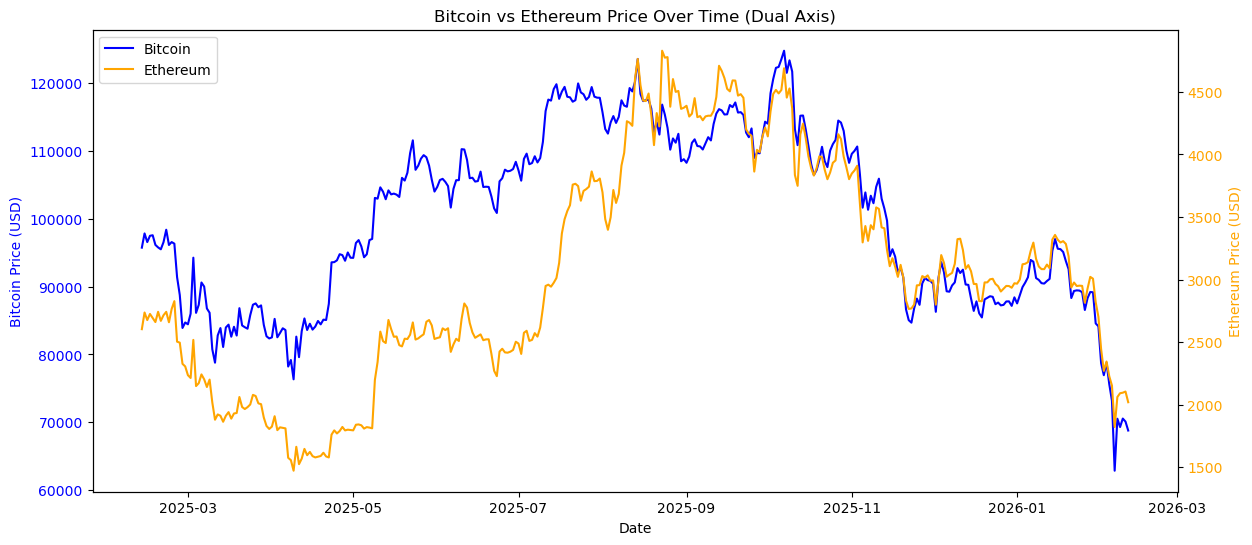

In [37]:
import matplotlib.pyplot as plt
#price over time 
plt.figure(figsize=(14,6))

# Separate data
btc = df[df['coin'] == 'bitcoin']
eth = df[df['coin'] == 'ethereum']

# Plot Bitcoin
ax = plt.gca()
ax.plot(btc['timestamp'], btc['price'], color='blue', label='Bitcoin')
ax.set_ylabel('Bitcoin Price (USD)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Plot Ethereum on secondary axis
ax2 = ax.twinx()
ax2.plot(eth['timestamp'], eth['price'], color='orange', label='Ethereum')
ax2.set_ylabel('Ethereum Price (USD)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Bitcoin vs Ethereum Price Over Time (Dual Axis)")
ax.set_xlabel("Date")

# Legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()



- Co-movement: Many price spikes in Bitcoin coincide with similar spikes in Ethereum suggesting a correlation between the two coins, likely due to market sentiment and shared investor base (btc movement could serve as a predictive feature for Ethereum in ML models and vice versa)
- Volatility: Ethereum's price appears more jagged compared to Bitcoin confirming its higher volatility



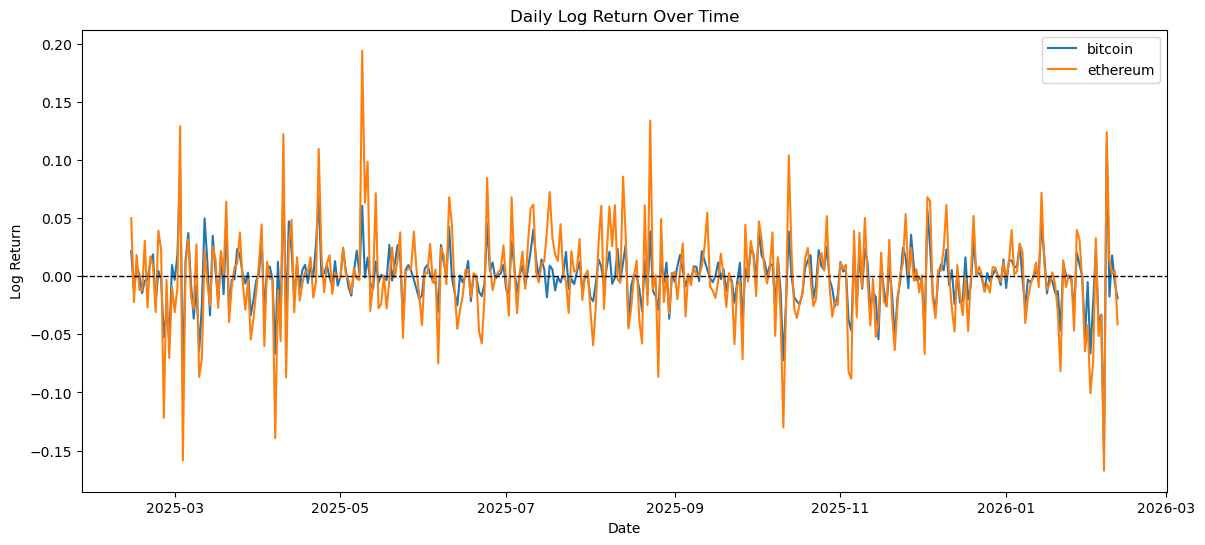

In [38]:
# Daily Log Return Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['log_return_1d'], label=coin)

plt.axhline(0, color='black', linestyle='--', linewidth=1)  # zero line
plt.title("Daily Log Return Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()


- Log Return:

Ethereum shows larger daily swings (both positive and negative) compared to Bitcoin, confirming higher daily volatility.
Spikes indicate sudden market movements potential risk periods or trading opportunities.

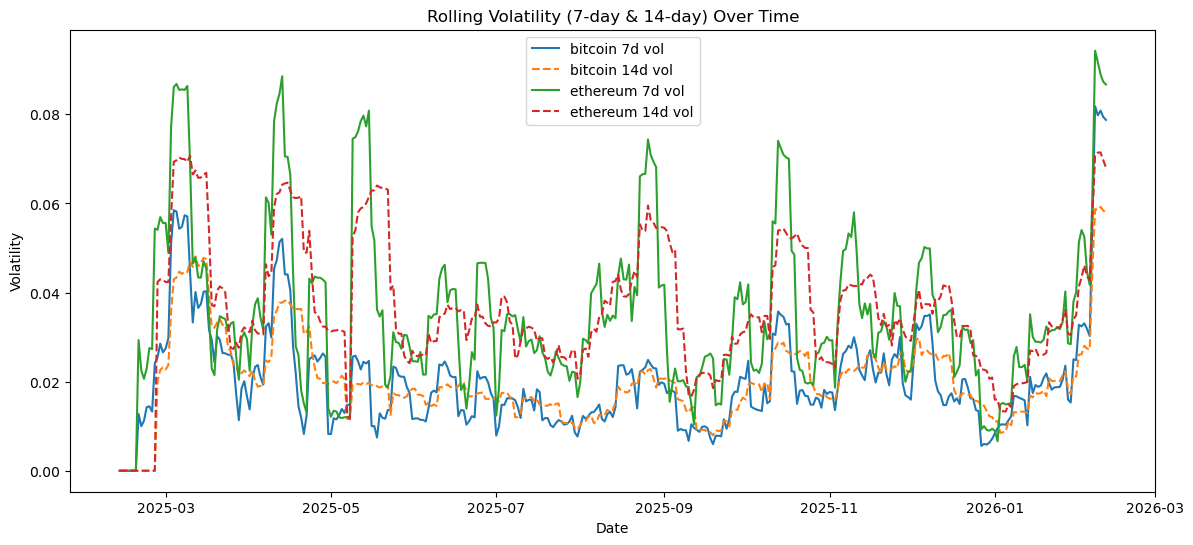

In [39]:
# Rolling Volatility Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['volatility_7d'], label=f'{coin} 7d vol')
    plt.plot(coin_df['timestamp'], coin_df['volatility_14d'], label=f'{coin} 14d vol', linestyle='--')  # <- add # for comment

plt.title("Rolling Volatility (7-day & 14-day) Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

- Rolling Volatility:

Bitcoin’s rolling volatility is relatively stable, Ethereum’s volatility fluctuates more widely.
7day vs 14day: shorter windows capture quick spikes, longer windows smooth the noise and show trend volatility
Log returns and rolling volatility are key inputs for LSTM models because they represent normalized price movement and risk dynamics..

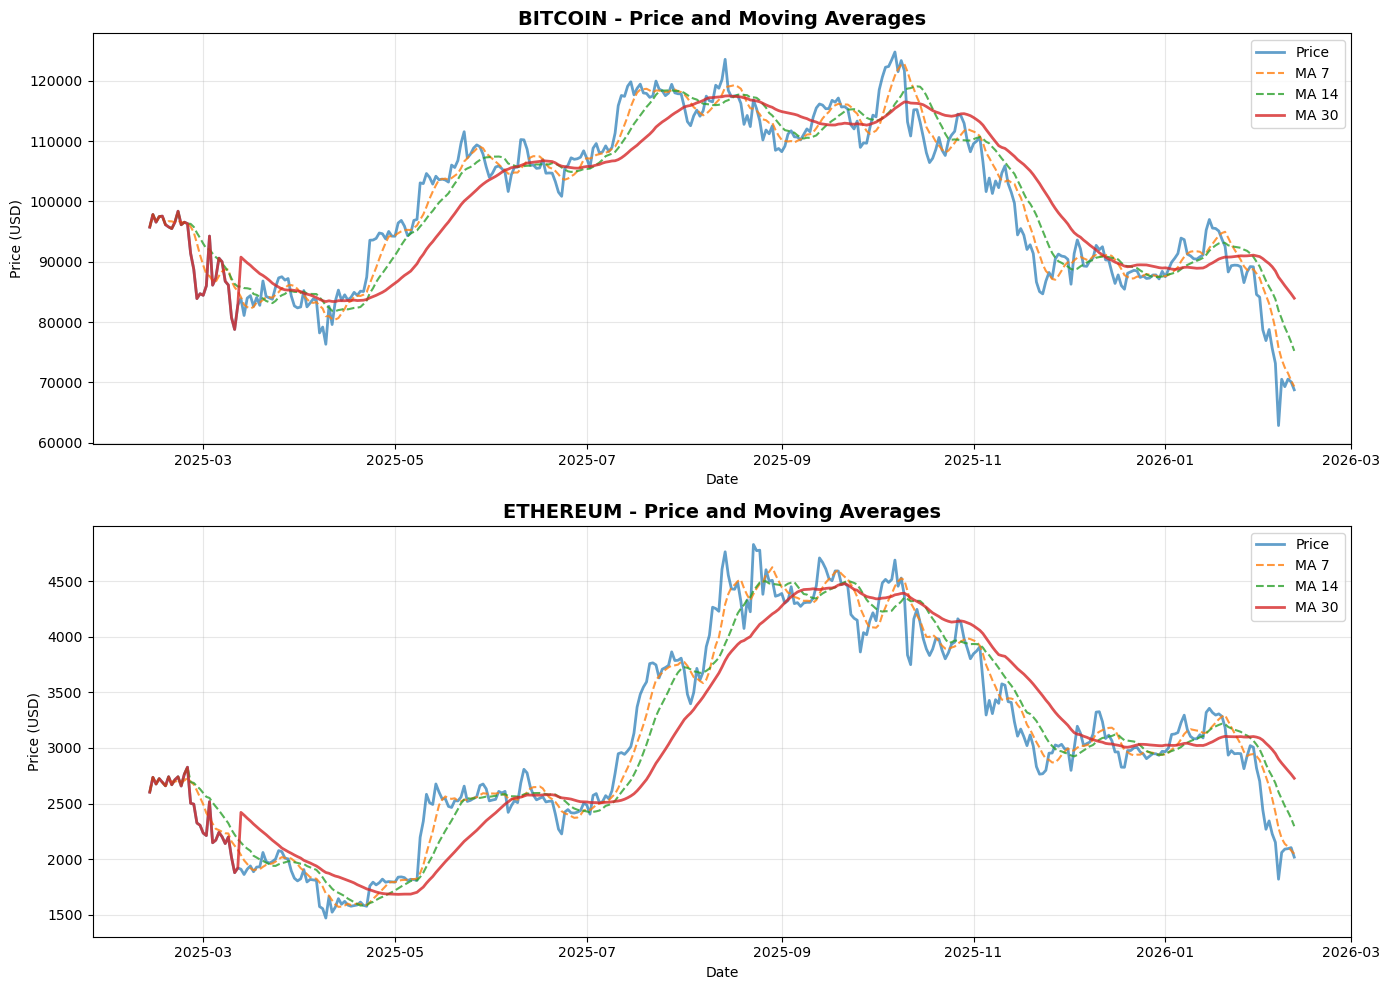

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Price + Moving Averages
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, coin_name in enumerate(["bitcoin", "ethereum"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price"], label="Price", linewidth=2, alpha=0.7)
    ax.plot(coin_data["timestamp"], coin_data["ma_7"], label="MA 7", linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_14"], label="MA 14", linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_30"], label="MA 30", linestyle="-", linewidth=2, alpha=0.8)
    
    ax.set_title(f"{coin_name.upper()} - Price and Moving Averages", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MA30 (long-term) → Smoothest, shows overall trend direction
- MA14 (medium-term) → Less smooth, reacts faster to changes
- MA7 (short-term) → Captures short-term volatility and price swings

1. MA Crossovers: 
- MA7 crosses above MA30 → Bullish signal (uptrend starting)
- MA7 crosses below MA30 → Bearish signal (downtrend starting)

2. Price Position Relative to MAs, When price is:
- Above all MAs → Strong uptrend, bullish momentum
- Below all MAs → Strong downtrend, bearish momentum
- Between MAs → Transition/consolidation phase, uncertainty

3. MA Spread (Distance Between MAs)
- Wide spread (MA7 far from MA30) → Strong trend (up or down)
- Narrow spread (MAs converging) → Weak trend, possible reversal coming

4. Support/Resistance Levels , MAs often act as:
- Support during uptrends (price bounces off MA30)
- Resistance during downtrends (price struggles to cross above MA30)

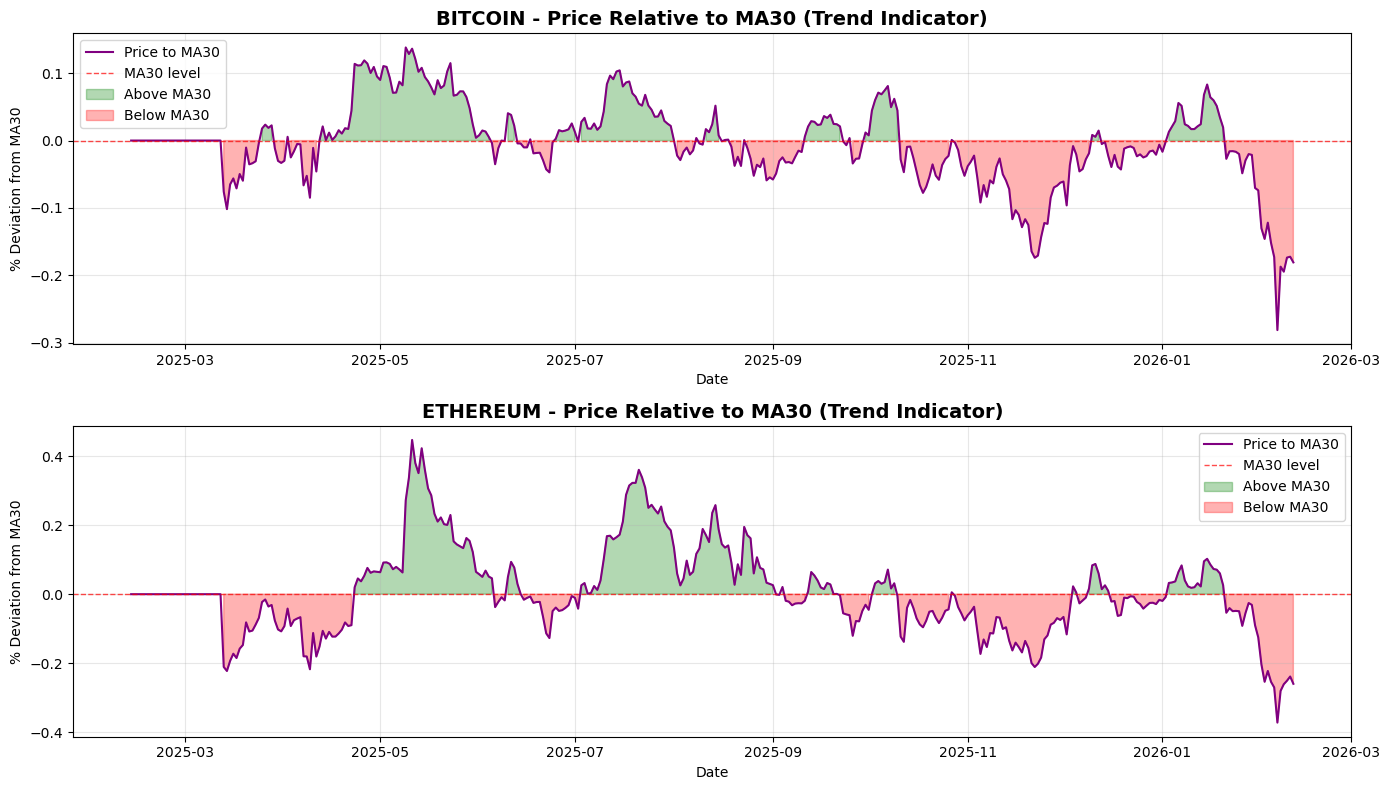

In [41]:
# Plot 2: Price relative to MA30 (shows when price is above/below long-term trend)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["bitcoin", "ethereum"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price_to_ma30"], label="Price to MA30", color="purple")
    ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="MA30 level")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"], 
                     where=(coin_data["price_to_ma30"] > 0), color="green", alpha=0.3, label="Above MA30")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"], 
                     where=(coin_data["price_to_ma30"] < 0), color="red", alpha=0.3, label="Below MA30")
    
    ax.set_title(f"{coin_name.upper()} - Price Relative to MA30 (Trend Indicator)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("% Deviation from MA30")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Lag Effect

- MA30 lags behind price movements during crashes, MA30 stays high while price drops → creates the gap in price relative to MA30 
- % deviation from 30-day trend: Green zone = price above trend (bullish) there is probability of bounce back
- % deviation from 30-day trend:Red zone = price below trend (bearish) there is probability of pull back
- When very negative (-0.20) → Bounce back happens → Mean reversion


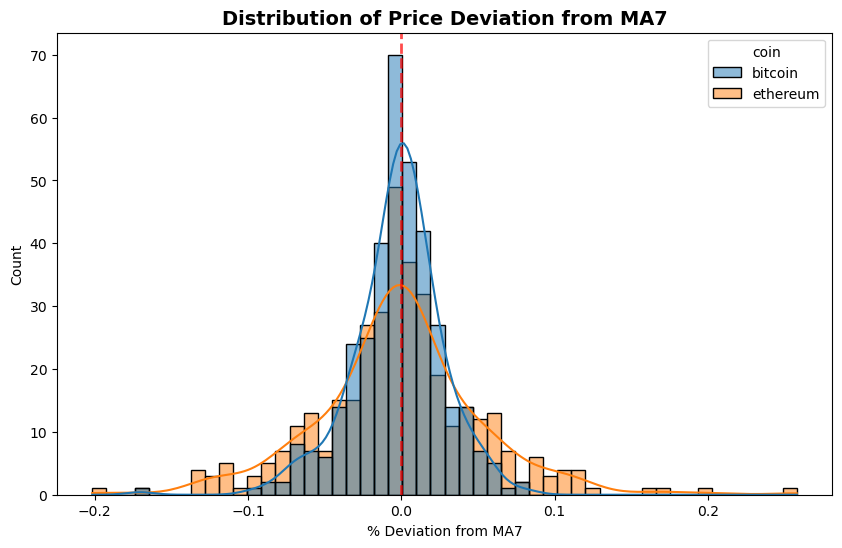

In [42]:
# Plot 3: Distribution of price_to_ma7 (useful for modeling)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(data=df, x="price_to_ma7", hue="coin", bins=50, kde=True, ax=ax)
ax.set_title("Distribution of Price Deviation from MA7", fontsize=14, fontweight="bold")
ax.set_xlabel("% Deviation from MA7")
ax.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.show()

1. Distribution of price_to_ma7 shows:How often price is above/below its 7-day average
- Price is above MA7 ~ 50% of the time for both coins, indicating a balance between bullish and bearish periods.
- No extreme skew → good for our model, won't be biased toward always predicting up or down

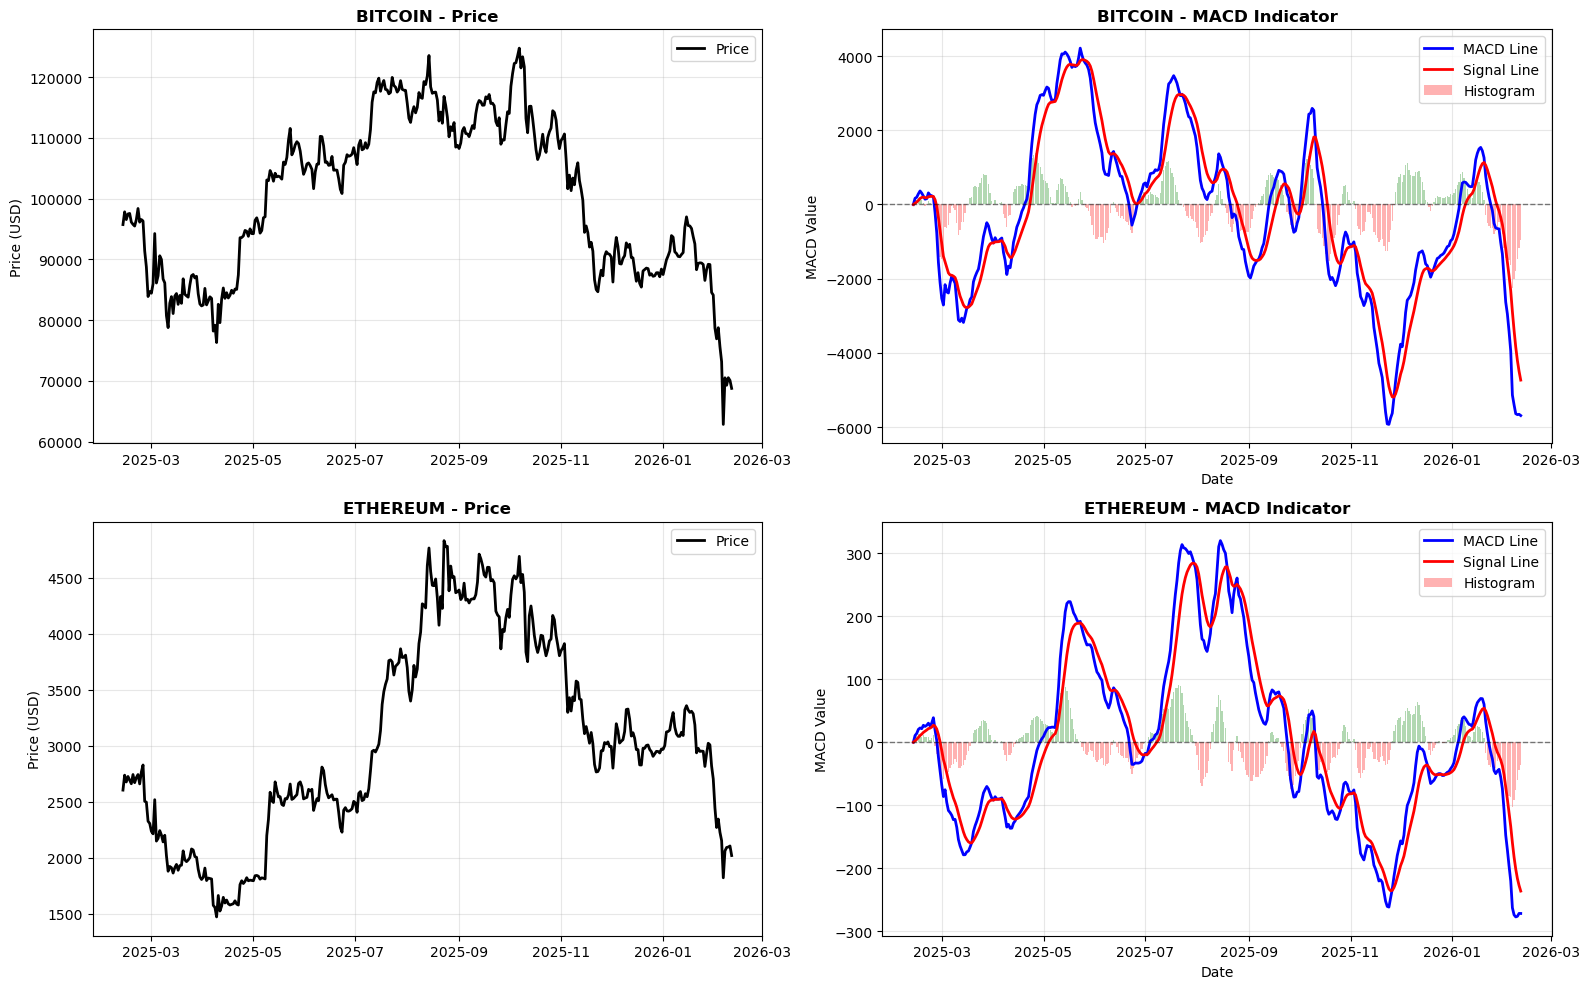

In [43]:
# EDA: MACD INDICATORS
# Plot 1: MACD Line, Signal Line, and Histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, coin_name in enumerate(["bitcoin", "ethereum"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    # Top plot: Price
    ax_price = axes[idx, 0]
    ax_price.plot(coin_data["timestamp"], coin_data["price"], label="Price", linewidth=2, color="black")
    ax_price.set_title(f"{coin_name.upper()} - Price", fontsize=12, fontweight="bold")
    ax_price.set_ylabel("Price (USD)")
    ax_price.legend()
    ax_price.grid(alpha=0.3)
    
    # Bottom plot: MACD
    ax_macd = axes[idx, 1]
    ax_macd.plot(coin_data["timestamp"], coin_data["macd"], label="MACD Line", linewidth=2, color="blue")
    ax_macd.plot(coin_data["timestamp"], coin_data["macd_signal"], label="Signal Line", linewidth=2, color="red")
    ax_macd.bar(coin_data["timestamp"], coin_data["macd_histogram"], label="Histogram", 
                alpha=0.3, color=coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red"))
    ax_macd.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax_macd.set_title(f"{coin_name.upper()} - MACD Indicator", fontsize=12, fontweight="bold")
    ax_macd.set_xlabel("Date")
    ax_macd.set_ylabel("MACD Value")
    ax_macd.legend()
    ax_macd.grid(alpha=0.3)

plt.tight_layout()
plt.show()


1. MACD Crossovers Work! that is a sweet pot for the prediction of price movements as it is a leading indicator that captures momentum shifts before they happen in the price action.
- Blue ( MACD) crosses above red (SIgnal Line)  → Price goes up 
- Blue ( MACD) crosses below red (SIgnal Line) → Price goes down 
- Crossover happens BEFORE price reversal (predictor)
- Lagging = Crossover happens AFTER price already moved (confirmation)

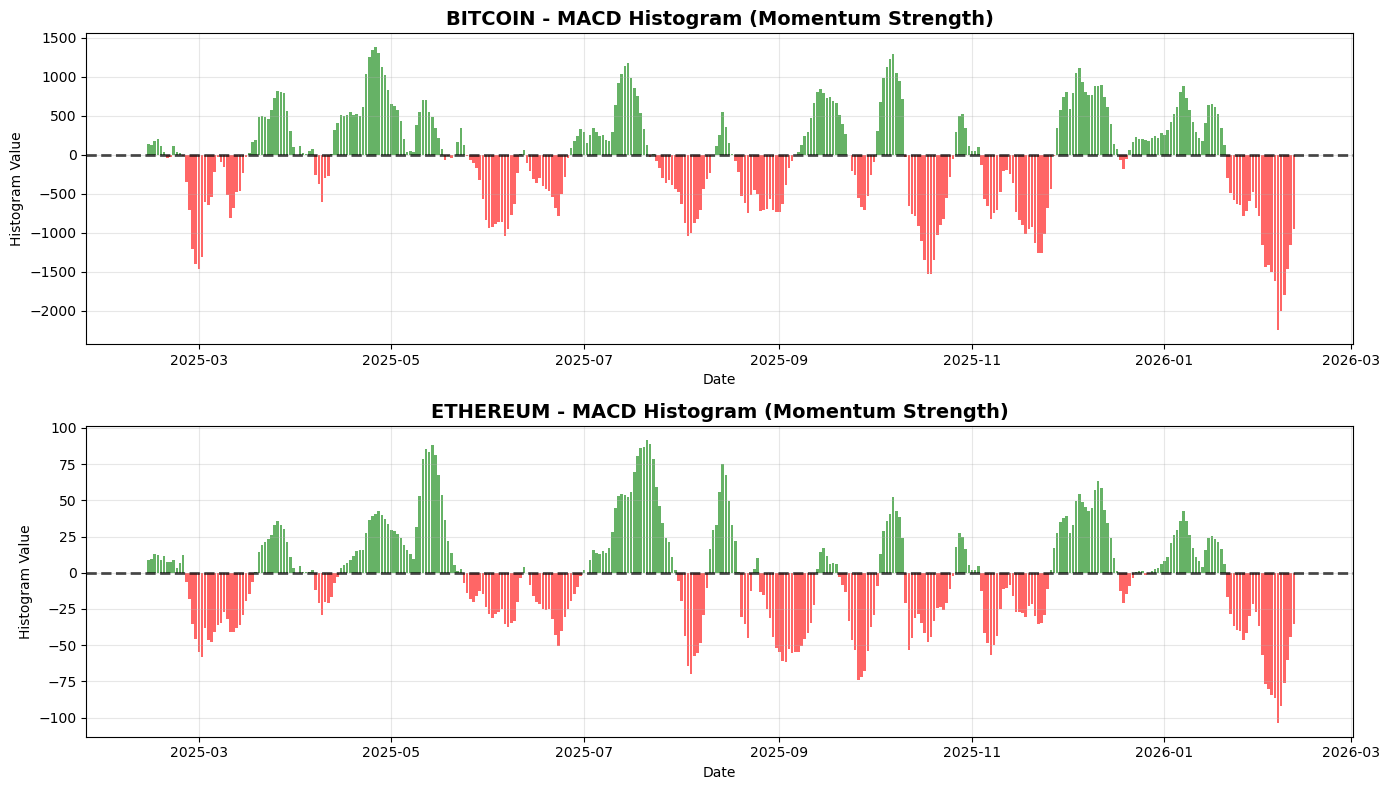

In [44]:
# Plot 2: MACD Histogram (Momentum Strength)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["bitcoin", "ethereum"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    # Color bars: green = bullish momentum, red = bearish momentum
    colors = coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red")
    ax.bar(coin_data["timestamp"], coin_data["macd_histogram"], color=colors, alpha=0.6)
    ax.axhline(0, color="black", linestyle="--", linewidth=2, alpha=0.7)
    
    ax.set_title(f"{coin_name.upper()} - MACD Histogram (Momentum Strength)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Histogram Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MACD histogram peaks (Momentum Exhaustion) SignalBEFORE price bottoms/tops (leading reversal signal)
- Green bars getting taller = Bulls accelerating (buying pressure increasing)
- Peak green bar = Maximum bullish momentum ,bars start shrinking after peak = Bulls getting tired .Signal: Uptrend losing steam → Reversal down coming soon
- Red bars getting taller = Bears accelerating (selling pressure increasing) . Peak red bar = Maximum bearish momentum
Bars start shrinking after peak = Bears getting tired . Signal: Downtrend losing steam → Reversal up coming soon!


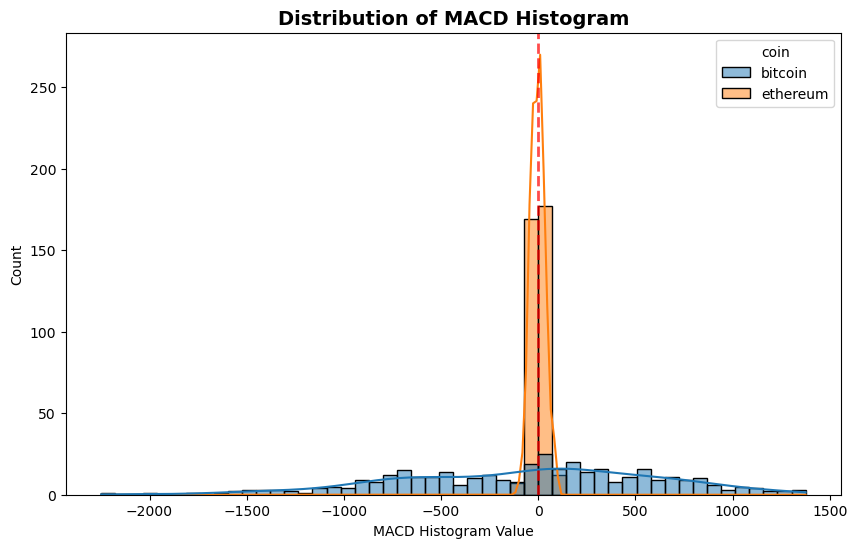

In [45]:
# Plot 3: Distribution of MACD Histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(data=df, x="macd_histogram", hue="coin", bins=50, kde=True, ax=ax)
ax.set_title("Distribution of MACD Histogram", fontsize=14, fontweight="bold")
ax.set_xlabel("MACD Histogram Value")
ax.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.show()

1. Distribution Centered Around 0

- Mean ≈ 0 → Balanced bull/bear periods over the year ,No systematic bias in one direction .Good for ML: Model won't learn to always predict up or down

- Left tail = Extreme negative values (like -1,420 from Feb crash) ,Skewed left = More extreme bearish momentum events than bullish


## Step 6: Production ready pipeline

* In this section we will create a production ready pipeline that will take raw CoinGecko data, apply the previous same preprocessing and feature engineering and always output exactly our final dataset with:same columns , same order, same feature definitions .
* That will allow as later to extract row data from coingecko and use it as prediction input for our Ml /LSTM model 

In [46]:
#Preprocessing function (rounding, typing, sorting, drops)
def preprocess_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Convert timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Sort (CRITICAL for time-series)
    df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)

    # Round only the features we will keep
    df["price"] = df["price"].round(2)
    df["market_cap"] = df["market_cap"].round(0)
    df["volume"] = df["volume"].round(0)

    # Drop unused categorical / snapshot columns immediately
    df = df.drop(
        columns=[
            "circulating_supply",
            "total_supply",
            "max_supply",
            "ath",
            "atl",
            "price_change_24h",
            "price_change_percentage_24h",
            "bullish_votes_pct",
            "bearish_votes_pct",
            "categories",
            "symbol",
            "name",
        ],
        errors="ignore",
    )

    return df


In [47]:
#feature engineering function
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Log return (stationary feature)
    df["log_return_1d"] = df.groupby("coin")["price"].transform(lambda x: np.log(x / x.shift(1)))

    # Short-term volatility (7d)
    df["volatility_7d"] = df.groupby("coin")["log_return_1d"].rolling(window=7).std().reset_index(level=0, drop=True)

    # RSI 14
    window = 14
    delta = df.groupby("coin")["price"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
    avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
    rs = avg_gain / avg_loss
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # Volume / market cap ratio
    df["volume_to_marketcap"] = df["volume"] / df["market_cap"]

    # Distance from ATH
    df["distance_from_ath"] = (df["price"] - df["ath"]) / df["ath"]

    # Drop snapshot circulating supply (we don't use it)
    df = df.drop(columns=["circulating_supply"], errors="ignore")

    return df


In [48]:
# Final dataset column order (clean version)
FINAL_COLUMNS = [
    "timestamp",
    "coin",
    "price",
    "log_return_1d",
    "volume",
    "market_cap",
    "volume_to_marketcap",
    "volatility_7d",
    "rsi_14",
    "distance_from_ath",
]

def finalize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop NaNs from rolling features
    rolling_features = ["volatility_7d", "rsi_14"]
    df = df.dropna(subset=rolling_features).reset_index(drop=True)

    # Enforce final column order (clean version)
    df = df[FINAL_COLUMNS]

    return df


In [49]:
# Production ready pipeline
def coingecko_preprocessing_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    df = preprocess_raw_data(df)
    df = engineer_features(df)
    df = finalize_dataset(df)
    return df